# 02 - Changepoint Detection

We compare four changepoint detection methods on **real STOXX 600 stocks**:

| # | Method | Idea |
|---|--------|------|
| 1 | **Brownian Motion (CUSUM)** | Page's sequential CUSUM — accumulates standardised deviations from a rolling reference mean. |
| 2 | **Jump Process** | Returns modelled as diffusion + jumps; flag days where the rolling z-score exceeds a threshold. |
| 3 | **Econometrics (rolling t-test)** | Welch two-sample t-test between pre/post windows detects a shift in the local mean. |
| 4 | **GP Matérn 3/2 + Changepoint kernel** | The paper's method (Wood, Roberts, Zohren 2022). |

### Ground truth

We define **known major market events** that acted as regime changes for
European equities. For each stock, detections are scored against these dates.

### Metrics

* **False Positive Rate (FPR)** — fraction of detections that are NOT near any known event.  
* **Recall** — fraction of known events that have at least one detection nearby.  
* **Mean delay** — average lag (days) between first detection and the event date.

In [48]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (14, 4), "figure.dpi": 100})

---
## 1. Load real stock data & define known events

In [49]:
df = pd.read_csv(
    "../data/processed/stoxx600/stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "price"],
)

# Stocks from different sectors / countries
STOCKS = [
    "ASML NA",   # Tech — Netherlands
    "TTE FP",    # Energy — France
    "BARC LN",   # Banks — UK
    "SAP GY",    # Tech — Germany
    "NOVN SE",   # Pharma — Switzerland
    "SAN SQ",    # Banks — Spain
    "ENEL IM",   # Utilities — Italy
    "NOVOB DC",  # Pharma — Denmark
]

# Known European equity regime changes
KNOWN_EVENTS = {

    # ===== 2015 regime shifts =====
    "SNB removes EUR/CHF floor":                pd.Timestamp("2015-01-15"),
    "ECB QE launch":                            pd.Timestamp("2015-01-22"),
    "Greek capital controls / bank holiday":    pd.Timestamp("2015-06-29"),
    "China Black Monday":                       pd.Timestamp("2015-08-24"),

    # ===== 2016-2018 =====
    "Brexit vote":                              pd.Timestamp("2016-06-24"),
    "Trump election 2016":                      pd.Timestamp("2016-11-09"),
    "Volmageddon (XIV implosion)":              pd.Timestamp("2018-02-05"),
    "Italy BTP selloff / populist coalition":   pd.Timestamp("2018-05-29"),
    "Q4 2018 selloff":                          pd.Timestamp("2018-10-10"),

    # ===== COVID =====
    "COVID crash":                              pd.Timestamp("2020-02-24"),
    "COVID recovery":                           pd.Timestamp("2020-03-23"),

    # ===== Inflation / war regime (2022) =====
    "Rate-hike selloff":                        pd.Timestamp("2022-01-05"),
    "Russia-Ukraine war":                       pd.Timestamp("2022-02-24"),
    "UK mini-budget (Truss)":                   pd.Timestamp("2022-09-26"),

    # ===== 2023 =====
    "SVB collapse":                             pd.Timestamp("2023-03-10"),
    "Credit Suisse / UBS rescue":               pd.Timestamp("2023-03-15"),
    "Israel-Hamas war":                         pd.Timestamp("2023-10-09"),

    # ===== 2024 =====
    "French snap election (Macron dissolution)": pd.Timestamp("2024-06-10"),
    "Yen carry trade unwind":                   pd.Timestamp("2024-08-05"),
    "Trump election 2024":                      pd.Timestamp("2024-11-06"),

    # ===== 2025 =====
    "DeepSeek AI shock":                        pd.Timestamp("2025-01-27"),
    "German debt brake / Zeitenwende":          pd.Timestamp("2025-03-05"),
    "Trump 'Liberation Day' tariffs":           pd.Timestamp("2025-04-03"),
    "Liberation Day selloff nadir":             pd.Timestamp("2025-04-07"),
    "Tariff 90-day pause rebound":              pd.Timestamp("2025-04-09"),

    # ===== 2026 =====
    "US/Iran war":                              pd.Timestamp("2026-02-28"),
}

print(f"Loaded {df['ticker'].nunique()} tickers, using {len(STOCKS)} for analysis")
print(f"Known events: {len(KNOWN_EVENTS)}")
for name, d in KNOWN_EVENTS.items():
    print(f"  {d.date()}  {name}")

Loaded 597 tickers, using 8 for analysis
Known events: 26
  2015-01-15  SNB removes EUR/CHF floor
  2015-01-22  ECB QE launch
  2015-06-29  Greek capital controls / bank holiday
  2015-08-24  China Black Monday
  2016-06-24  Brexit vote
  2016-11-09  Trump election 2016
  2018-02-05  Volmageddon (XIV implosion)
  2018-05-29  Italy BTP selloff / populist coalition
  2018-10-10  Q4 2018 selloff
  2020-02-24  COVID crash
  2020-03-23  COVID recovery
  2022-01-05  Rate-hike selloff
  2022-02-24  Russia-Ukraine war
  2022-09-26  UK mini-budget (Truss)
  2023-03-10  SVB collapse
  2023-03-15  Credit Suisse / UBS rescue
  2023-10-09  Israel-Hamas war
  2024-06-10  French snap election (Macron dissolution)
  2024-08-05  Yen carry trade unwind
  2024-11-06  Trump election 2024
  2025-01-27  DeepSeek AI shock
  2025-03-05  German debt brake / Zeitenwende
  2025-04-03  Trump 'Liberation Day' tariffs
  2025-04-07  Liberation Day selloff nadir
  2025-04-09  Tariff 90-day pause rebound
  2026-02-28 

In [50]:
def load_stock(ticker: str) -> tuple[pd.DatetimeIndex, np.ndarray, np.ndarray, list[int]]:
    """Load a stock and map known events to return-array indices.

    Returns
    -------
    dates      : DatetimeIndex of price dates.
    prices     : price array (same length as dates).
    returns    : daily simple returns (len = len(dates) - 1).
    event_idxs : list of indices into `returns` for each known event.
    """
    s = df.loc[df["ticker"] == ticker, ["date", "price"]].sort_values("date").reset_index(drop=True)
    dates = s["date"]
    prices = s["price"].values
    returns = np.diff(prices) / prices[:-1]  # simple returns

    # Map event dates -> nearest index in return array
    event_idxs = []
    for ev_date in KNOWN_EVENTS.values():
        diffs = (dates - ev_date).abs()
        nearest = diffs.idxmin()
        # Only include if within 5 trading days of the target
        if diffs[nearest].days <= 7:
            idx = min(nearest, len(returns) - 1)  # returns is 1 shorter
            event_idxs.append(idx)

    return dates, prices, returns, sorted(set(event_idxs))


# Quick check
dates_ex, prices_ex, returns_ex, events_ex = load_stock("ASML NA")
print(f"ASML NA: {len(returns_ex)} returns, {len(events_ex)} events matched")

ASML NA: 3463 returns, 26 events matched


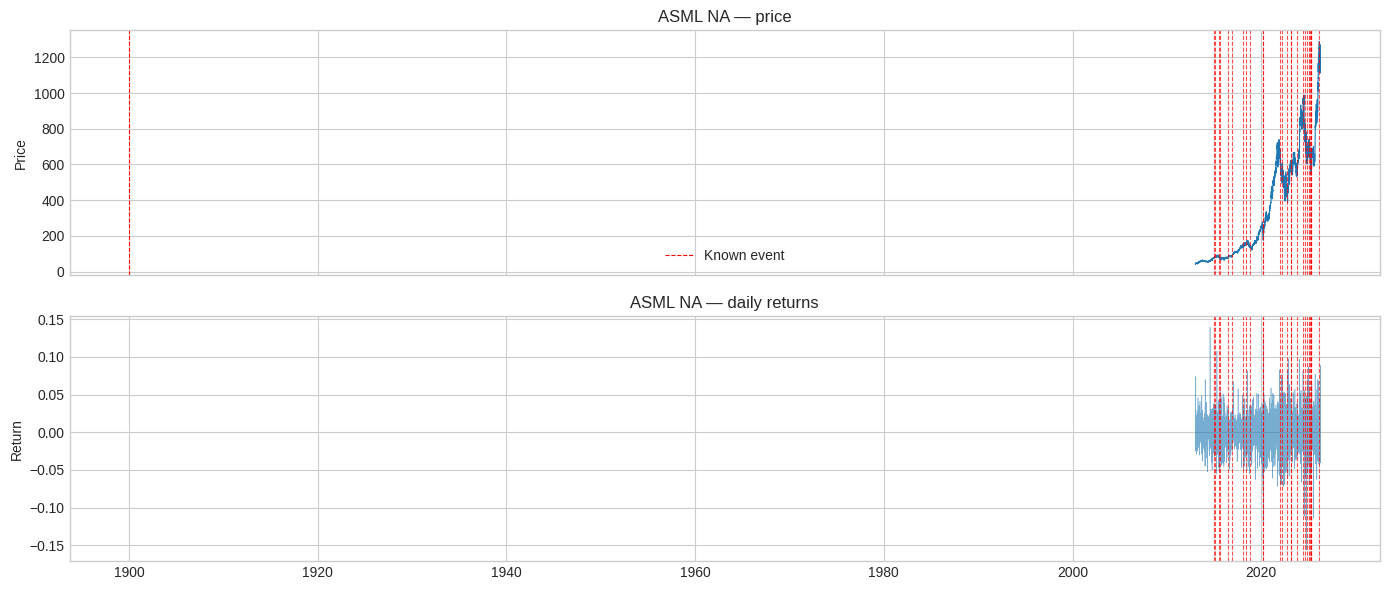

In [51]:
# Visualise the primary stock with known events
PRIMARY = "ASML NA"
dates_p, prices_p, returns_p, events_p = load_stock(PRIMARY)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(dates_p, prices_p, linewidth=0.8)
axes[0].set_title(f"{PRIMARY} — price")
axes[0].set_ylabel("Price")

axes[1].plot(dates_p.iloc[1:], returns_p, linewidth=0.4, alpha=0.6)
axes[1].set_title(f"{PRIMARY} — daily returns")
axes[1].set_ylabel("Return")

for ev_name, ev_date in KNOWN_EVENTS.items():
    for ax in axes:
        ax.axvline(ev_date, color="red", ls="--", lw=0.8, alpha=0.7)
# Legend entry
axes[0].axvline(pd.Timestamp("1900-01-01"), color="red", ls="--", lw=0.8, label="Known event")
axes[0].legend()

plt.tight_layout()
plt.show()

---
## 2. Evaluation framework

In [52]:
def evaluate_detections(
    detected: list[int],
    true_cps: list[int],
    tol: int = 20,
) -> dict:
    """Score detected changepoints against ground truth.

    Parameters
    ----------
    detected : list of day indices flagged by the detector.
    true_cps : list of ground-truth event indices.
    tol      : tolerance window (±days). Detection within ±tol of a
               true CP counts as a true positive.
    """
    detected = sorted(set(detected))
    true_cps = sorted(true_cps)

    if len(detected) == 0:
        return {"fpr": 0.0, "recall": 0.0, "n_det": 0,
                "n_tp": 0, "n_fp": 0, "delays": [], "mean_delay": np.nan}

    tp_dets = set()
    matched = {}  # true_cp -> closest detection

    for d in detected:
        for cp in true_cps:
            if abs(d - cp) <= tol:
                tp_dets.add(d)
                if cp not in matched or abs(d - cp) < abs(matched[cp] - cp):
                    matched[cp] = d
                break

    n_tp = len(tp_dets)
    n_fp = len(detected) - n_tp
    fpr = n_fp / len(detected)
    recall = len(matched) / len(true_cps) if true_cps else 1.0
    delays = [matched[cp] - cp for cp in true_cps if cp in matched]
    mean_delay = float(np.mean(delays)) if delays else np.nan

    return {"fpr": fpr, "recall": recall, "n_det": len(detected),
            "n_tp": n_tp, "n_fp": n_fp, "delays": delays, "mean_delay": mean_delay}

---
## 3. Method 1 — Brownian Motion / CUSUM

Page's sequential CUSUM tracks deviations from a reference mean estimated
on a trailing window. A changepoint is flagged when the accumulated
deviation exceeds a threshold.

In [53]:
def detect_cusum(
    returns: np.ndarray,
    ref_window: int = 60,
    threshold: float = 4.0,
    cooldown: int = 20,
) -> list[int]:
    """Page's two-sided CUSUM for mean-shift detection."""
    n = len(returns)
    detections = []
    last_det = -cooldown - 1
    k = 0.5
    s_pos, s_neg = 0.0, 0.0

    for t in range(ref_window, n):
        ref = returns[t - ref_window : t]
        mu, sigma = ref.mean(), ref.std(ddof=1)
        if sigma < 1e-12:
            continue
        z = (returns[t] - mu) / sigma
        s_pos = max(0.0, s_pos + z - k)
        s_neg = max(0.0, s_neg - z - k)
        if max(s_pos, s_neg) > threshold and (t - last_det) > cooldown:
            detections.append(t)
            last_det = t
            s_pos = s_neg = 0.0
    return detections

CUSUM on ASML NA: 31 det, FPR=74%, Recall=27%, Delay=-6.3d


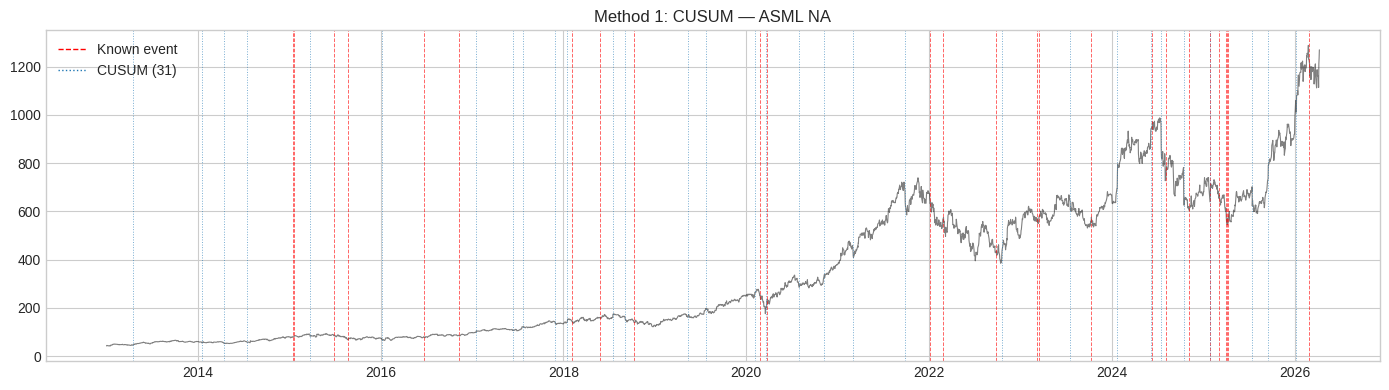

In [54]:
det_cusum = detect_cusum(returns_p, ref_window=60, threshold=4.0, cooldown=30)
res_cusum = evaluate_detections(det_cusum, events_p, tol=20)
print(f"CUSUM on {PRIMARY}: {res_cusum['n_det']} det, "
      f"FPR={res_cusum['fpr']:.0%}, Recall={res_cusum['recall']:.0%}, "
      f"Delay={res_cusum['mean_delay']:.1f}d")

fig, ax = plt.subplots()
ax.plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.5)
for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.6)
for d in det_cusum:
    ax.axvline(dates_p.iloc[d+1], color="C0", ls=":", lw=0.7, alpha=0.6)
ax.plot([], [], color="red", ls="--", lw=1, label="Known event")
ax.plot([], [], color="C0", ls=":", lw=1, label=f"CUSUM ({len(det_cusum)})")
ax.set_title(f"Method 1: CUSUM — {PRIMARY}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Method 2 — Jump Process

Flag days where the absolute standardised return (rolling z-score) exceeds
a threshold — proxy for jumps in a diffusion + Poisson-jump model.

In [55]:
def detect_jump(
    returns: np.ndarray,
    window: int = 60,
    threshold: float = 3.0,
    cooldown: int = 20,
) -> list[int]:
    """Jump detection via rolling z-score."""
    n = len(returns)
    detections = []
    last_det = -cooldown - 1
    for t in range(window, n):
        w = returns[t - window : t]
        mu, sigma = w.mean(), w.std(ddof=1)
        if sigma < 1e-12:
            continue
        if abs(returns[t] - mu) / sigma > threshold and (t - last_det) > cooldown:
            detections.append(t)
            last_det = t
    return detections

Jump on ASML NA: 53 det, FPR=77%, Recall=46%, Delay=0.4d


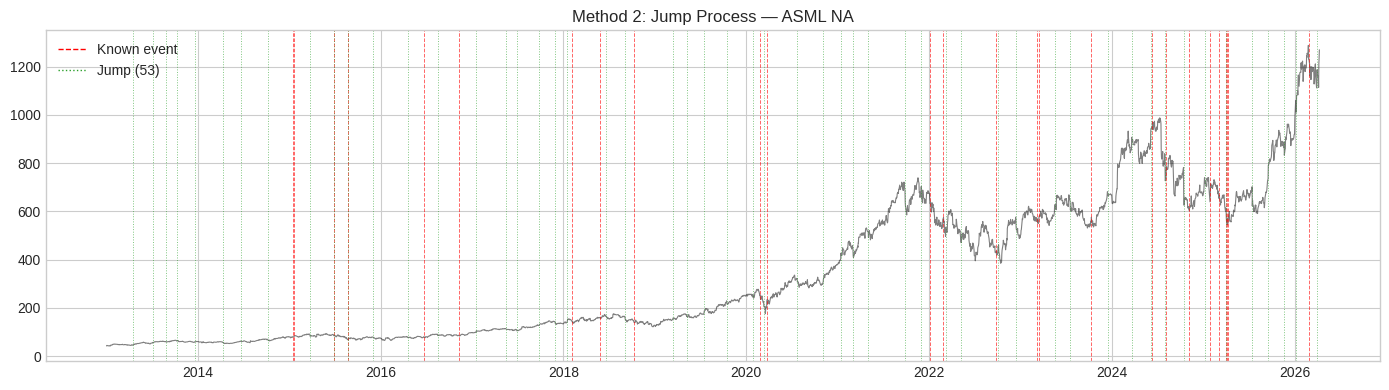

In [56]:
det_jump = detect_jump(returns_p, window=40, threshold=2.5, cooldown=30)
res_jump = evaluate_detections(det_jump, events_p, tol=20)
print(f"Jump on {PRIMARY}: {res_jump['n_det']} det, "
      f"FPR={res_jump['fpr']:.0%}, Recall={res_jump['recall']:.0%}, "
      f"Delay={res_jump['mean_delay']:.1f}d")

fig, ax = plt.subplots()
ax.plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.5)
for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.6)
for d in det_jump:
    ax.axvline(dates_p.iloc[d+1], color="C2", ls=":", lw=0.7, alpha=0.6)
ax.plot([], [], color="red", ls="--", lw=1, label="Known event")
ax.plot([], [], color="C2", ls=":", lw=1, label=f"Jump ({len(det_jump)})")
ax.set_title(f"Method 2: Jump Process — {PRIMARY}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Method 3 — Econometrics (rolling two-sample t-test)

Welch's t-test comparing the mean of a pre-window vs a post-window.

In [57]:
def detect_ttest(
    returns: np.ndarray,
    window: int = 30,
    alpha: float = 0.001,
    cooldown: int = 20,
) -> list[int]:
    """Rolling Welch t-test for mean shift."""
    n = len(returns)
    detections = []
    last_det = -cooldown - 1
    for t in range(2 * window, n):
        pre = returns[t - 2 * window : t - window]
        post = returns[t - window : t]
        _, p = stats.ttest_ind(pre, post, equal_var=False)
        if p < alpha and (t - last_det) > cooldown:
            detections.append(t)
            last_det = t
    return detections

t-test on ASML NA: 5 det, FPR=80%, Recall=4%, Delay=17.0d


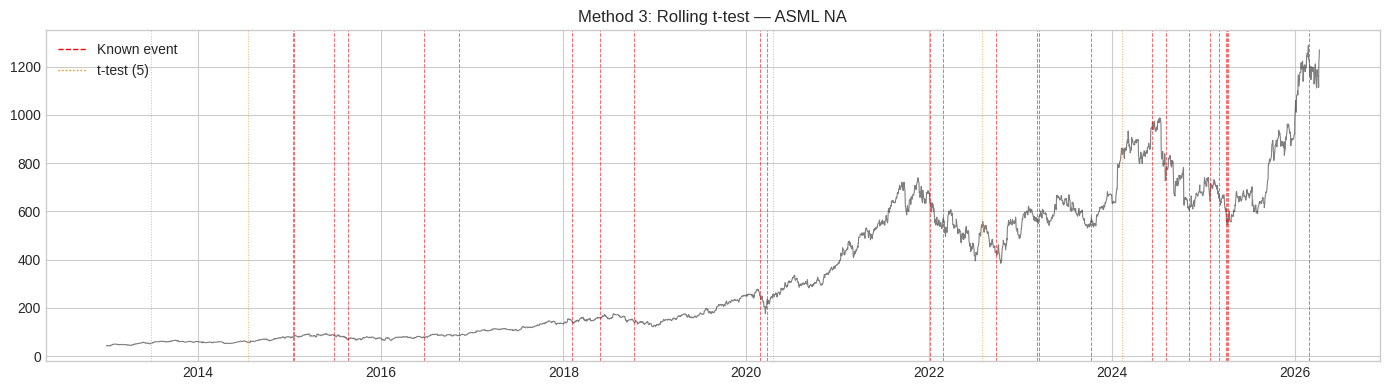

In [58]:
det_ttest = detect_ttest(returns_p, window=20, alpha=0.01, cooldown=30)
res_ttest = evaluate_detections(det_ttest, events_p, tol=20)
print(f"t-test on {PRIMARY}: {res_ttest['n_det']} det, "
      f"FPR={res_ttest['fpr']:.0%}, Recall={res_ttest['recall']:.0%}, "
      f"Delay={res_ttest['mean_delay']:.1f}d")

fig, ax = plt.subplots()
ax.plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.5)
for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.6)
for d in det_ttest:
    ax.axvline(dates_p.iloc[d+1], color="C1", ls=":", lw=0.7, alpha=0.6)
ax.plot([], [], color="red", ls="--", lw=1, label="Known event")
ax.plot([], [], color="C1", ls=":", lw=1, label=f"t-test ({len(det_ttest)})")
ax.set_title(f"Method 3: Rolling t-test — {PRIMARY}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Method 4 — GP Matérn 3/2 + Changepoint Kernel (paper)

From Wood, Roberts & Zohren (2022):

1. Take a rolling window of `lbw` standardised returns.
2. Fit a base GP (single Matérn 3/2 kernel) → $\text{NLML}_M$.
3. Fit a changepoint GP (sigmoid blend of two Matérn 3/2) → $\text{NLML}_{CP}$.
4. Severity $\nu = \sigma(\text{NLML}_M - \text{NLML}_{CP}) \in (0,1)$.
5. Location $\gamma = c / (l-1) \in (0,1)$.

Flag a CP when $\nu >$ threshold and $\gamma > 0.5$.

In [59]:
from src.cpd import cpd_scores


def detect_gp_cpd(
    returns: np.ndarray,
    lbw: int = 21,
    nu_threshold: float = 0.85,
    gamma_min: float = 0.5,
    cooldown: int = 20,
    stride: int = 1,
) -> tuple[list[int], np.ndarray, np.ndarray]:
    """GP-based CPD using the paper's Matérn 3/2 changepoint kernel."""
    n = len(returns)
    nu_arr = np.full(n, np.nan)
    gamma_arr = np.full(n, np.nan)
    detections = []
    last_det = -cooldown - 1

    for t in range(lbw, n, stride):
        window = returns[t - lbw : t]
        nu, gamma = cpd_scores(window, lbw)
        nu_arr[t] = nu
        gamma_arr[t] = gamma
        if nu > nu_threshold and gamma > gamma_min and (t - last_det) > cooldown:
            detections.append(t)
            last_det = t

    return detections, nu_arr, gamma_arr

In [60]:
%%time
det_gp, nu_arr, gamma_arr = detect_gp_cpd(
    returns_p, lbw=21, nu_threshold=0.85, gamma_min=0.5, cooldown=30, stride=10
)
res_gp = evaluate_detections(det_gp, events_p, tol=20)
print(f"GP CPD on {PRIMARY}: {res_gp['n_det']} det, "
      f"FPR={res_gp['fpr']:.0%}, Recall={res_gp['recall']:.0%}, "
      f"Delay={res_gp['mean_delay']:.1f}d")

GP CPD on ASML NA: 47 det, FPR=74%, Recall=46%, Delay=-2.4d
CPU times: user 2min 8s, sys: 1e+03 ns, total: 2min 8s
Wall time: 12.9 s


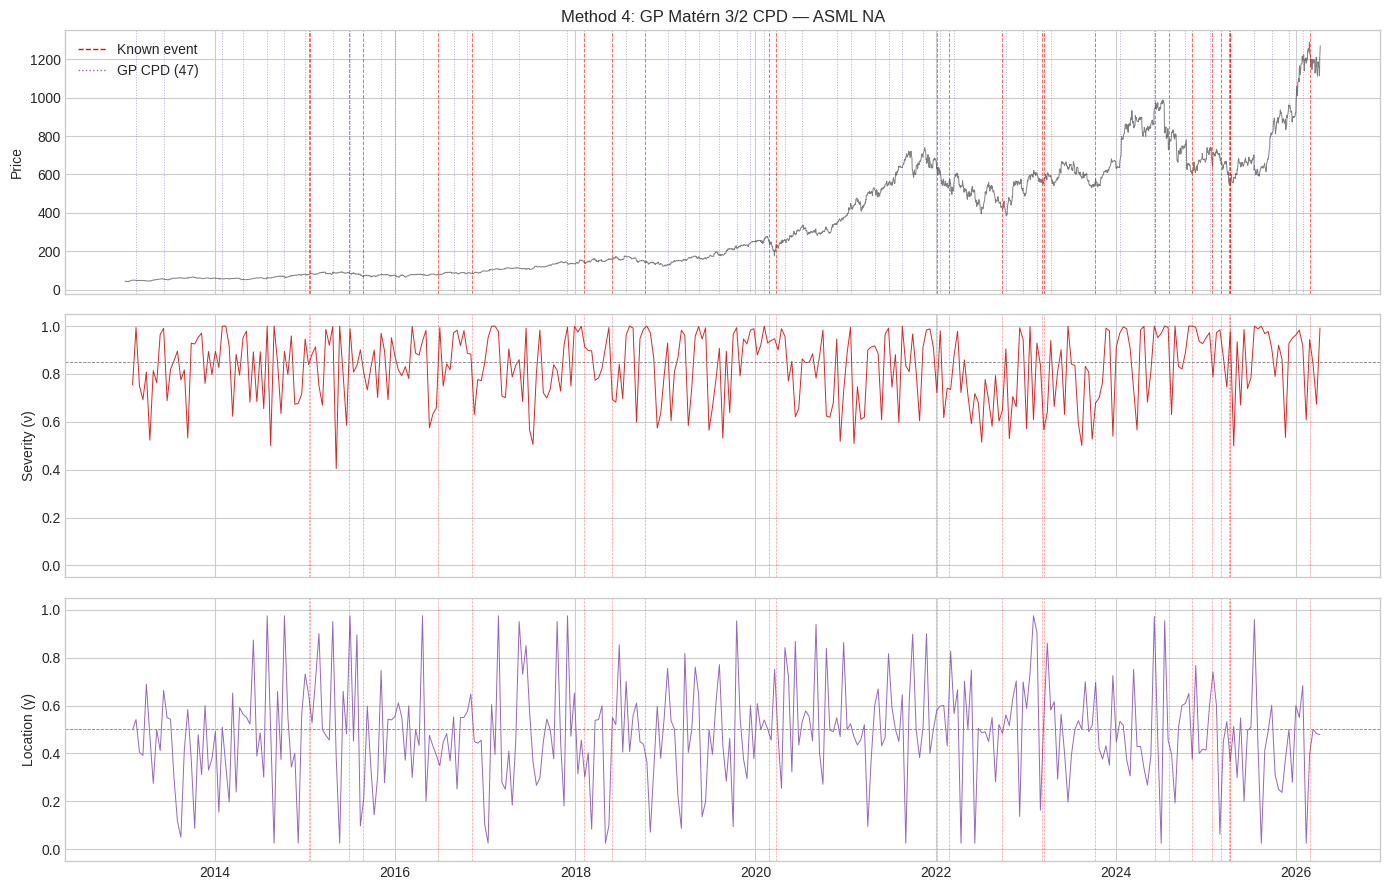

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Price + detections
ax = axes[0]
ax.plot(dates_p, prices_p, lw=0.7, color="black", alpha=0.5)
for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.6)
for d in det_gp:
    ax.axvline(dates_p.iloc[d+1], color="C4", ls=":", lw=0.7, alpha=0.6)
ax.plot([], [], color="red", ls="--", lw=1, label="Known event")
ax.plot([], [], color="C4", ls=":", lw=1, label=f"GP CPD ({len(det_gp)})")
ax.set_title(f"Method 4: GP Matérn 3/2 CPD — {PRIMARY}")
ax.set_ylabel("Price")
ax.legend()

# Severity
valid = ~np.isnan(nu_arr)
t_idx = np.where(valid)[0]
axes[1].plot(dates_p.iloc[t_idx + 1], nu_arr[t_idx], lw=0.7, color="C3")
axes[1].axhline(0.85, color="gray", ls="--", lw=0.6)
for ev_date in KNOWN_EVENTS.values():
    axes[1].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.4)
axes[1].set_ylabel("Severity (ν)")
axes[1].set_ylim(-0.05, 1.05)

# Location
axes[2].plot(dates_p.iloc[t_idx + 1], gamma_arr[t_idx], lw=0.7, color="C4")
axes[2].axhline(0.5, color="gray", ls="--", lw=0.6)
for ev_date in KNOWN_EVENTS.values():
    axes[2].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.4)
axes[2].set_ylabel("Location (γ)")
axes[2].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

---
## 7. Single-stock comparison — all methods

In [62]:
results_single = {
    "CUSUM (Brownian)": res_cusum,
    "Jump Process":     res_jump,
    "Rolling t-test":   res_ttest,
    "GP Matérn 3/2":    res_gp,
}

summary = pd.DataFrame({
    name: {
        "Detections": r["n_det"],
        "True Positives": r["n_tp"],
        "False Positives": r["n_fp"],
        "FPR": f"{r['fpr']:.1%}",
        "Recall": f"{r['recall']:.1%}",
        "Mean delay (d)": f"{r['mean_delay']:.1f}" if not np.isnan(r['mean_delay']) else "—",
    }
    for name, r in results_single.items()
}).T

print(f"Results on {PRIMARY} ({len(events_p)} known events, tol=±20d)")
summary

Results on ASML NA (26 known events, tol=±20d)


,Detections,True Positives,False Positives,FPR,Recall,Mean delay (d)
CUSUM (Brownian),31,8,23,74.2%,26.9%,-6.3
Jump Process,53,12,41,77.4%,46.2%,0.4
Rolling t-test,5,1,4,80.0%,3.8%,17.0
GP Matérn 3/2,47,12,35,74.5%,46.2%,-2.4


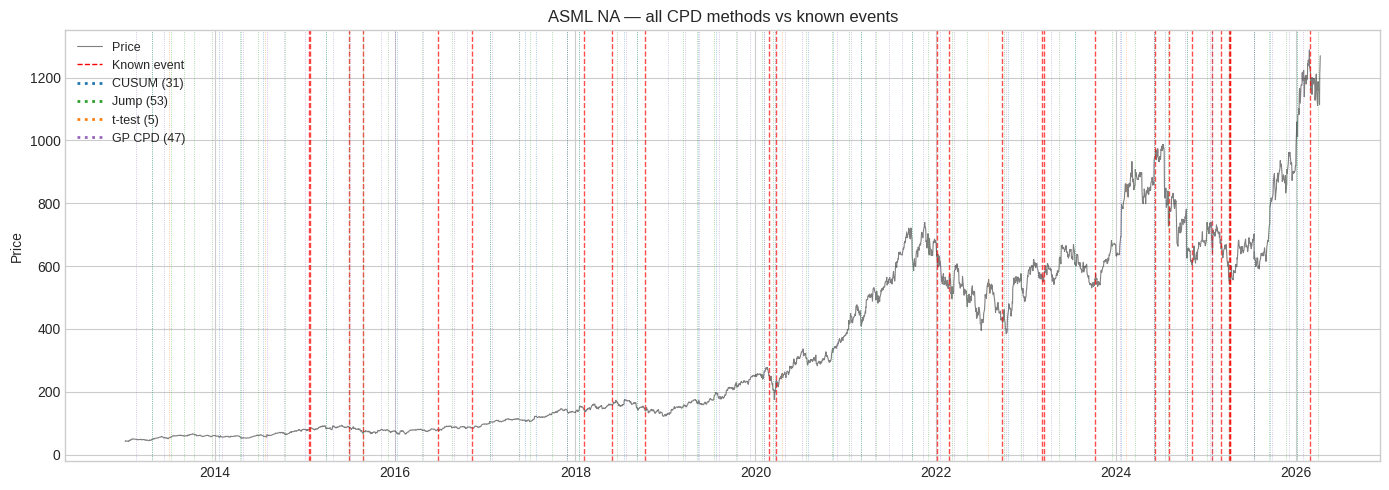

In [63]:
# All methods on one chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.5, label="Price")

for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=1, alpha=0.7)
ax.plot([], [], color="red", ls="--", lw=1, label="Known event")

all_dets = [
    (det_cusum, "CUSUM",  "C0"),
    (det_jump,  "Jump",   "C2"),
    (det_ttest, "t-test", "C1"),
    (det_gp,    "GP CPD", "C4"),
]
for dets, name, color in all_dets:
    for d in dets:
        ax.axvline(dates_p.iloc[d+1], color=color, ls=":", lw=0.6, alpha=0.5)
    if dets:
        ax.plot([], [], color=color, ls=":", lw=2, label=f"{name} ({len(dets)})")

ax.set_title(f"{PRIMARY} — all CPD methods vs known events")
ax.set_ylabel("Price")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Multi-stock evaluation

Run all four methods on 8 stocks across sectors and countries, then
aggregate FPR / Recall.

In [64]:
%%time
METHOD_NAMES = ["CUSUM (Brownian)", "Jump Process", "Rolling t-test", "GP Matérn 3/2"]
multi = {m: {"fpr": [], "recall": [], "delay": []} for m in METHOD_NAMES}

for ticker in STOCKS:
    _, _, ret, ev_idx = load_stock(ticker)
    if len(ev_idx) == 0:
        continue

    detectors = {
        "CUSUM (Brownian)": detect_cusum(ret, ref_window=60, threshold=4.0, cooldown=30),
        "Jump Process":     detect_jump(ret, window=40, threshold=2.5, cooldown=30),
        "Rolling t-test":   detect_ttest(ret, window=20, alpha=0.01, cooldown=30),
        "GP Matérn 3/2":    detect_gp_cpd(ret, lbw=21, nu_threshold=0.85, cooldown=30, stride=10)[0],
    }

    for name, dets in detectors.items():
        ev = evaluate_detections(dets, ev_idx, tol=20)
        multi[name]["fpr"].append(ev["fpr"])
        multi[name]["recall"].append(ev["recall"])
        multi[name]["delay"].append(ev["mean_delay"])

    print(f"  {ticker}: done")

print(f"\nMulti-stock evaluation done ({len(STOCKS)} stocks).")

  ASML NA: done
  TTE FP: done
  BARC LN: done
  SAP GY: done
  NOVN SE: done
  SAN SQ: done
  ENEL IM: done
  NOVOB DC: done

Multi-stock evaluation done (8 stocks).
CPU times: user 18min 37s, sys: 31 ms, total: 18min 37s
Wall time: 1min 58s


In [65]:
multi_summary = pd.DataFrame({
    name: {
        "Mean FPR": f"{np.mean(v['fpr']):.1%}",
        "Std FPR": f"{np.std(v['fpr']):.1%}",
        "Mean Recall": f"{np.mean(v['recall']):.1%}",
        "Std Recall": f"{np.std(v['recall']):.1%}",
        "Mean delay (d)": f"{np.nanmean(v['delay']):.1f}",
    }
    for name, v in multi.items()
}).T

print(f"Aggregated across {len(STOCKS)} STOXX 600 stocks, {len(KNOWN_EVENTS)} known events")
multi_summary

Aggregated across 8 STOXX 600 stocks, 26 known events


,Mean FPR,Std FPR,Mean Recall,Std Recall,Mean delay (d)
CUSUM (Brownian),59.0%,10.8%,45.2%,11.3%,-1.2
Jump Process,70.4%,3.4%,60.1%,6.9%,-1.4
Rolling t-test,73.9%,16.6%,6.7%,3.7%,7.6
GP Matérn 3/2,73.9%,4.8%,48.6%,8.6%,-0.1


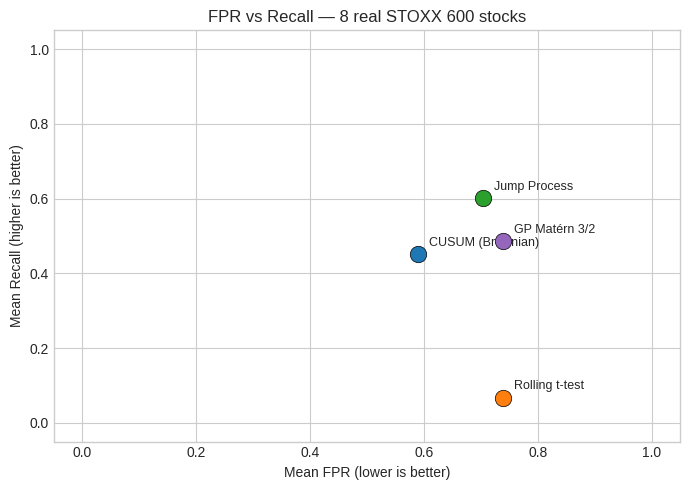

In [66]:
# FPR vs Recall scatter
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["C0", "C2", "C1", "C4"]
for (name, v), c in zip(multi.items(), colors):
    ax.scatter(
        np.mean(v["fpr"]), np.mean(v["recall"]),
        s=140, color=c, zorder=5, edgecolors="black", linewidth=0.5,
    )
    ax.annotate(
        name, (np.mean(v["fpr"]), np.mean(v["recall"])),
        textcoords="offset points", xytext=(8, 6), fontsize=9,
    )
ax.set_xlabel("Mean FPR (lower is better)")
ax.set_ylabel("Mean Recall (higher is better)")
ax.set_title(f"FPR vs Recall — {len(STOCKS)} real STOXX 600 stocks")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [67]:
# Per-stock detail for each method
rows = []
for ticker in STOCKS:
    _, _, ret, ev_idx = load_stock(ticker)
    if len(ev_idx) == 0:
        continue
    for name, det_fn, kw in [
        ("CUSUM", detect_cusum, dict(ref_window=60, threshold=4.0, cooldown=30)),
        ("Jump",  detect_jump,  dict(window=40, threshold=2.5, cooldown=30)),
        ("t-test", detect_ttest, dict(window=20, alpha=0.01, cooldown=30)),
    ]:
        dets = det_fn(ret, **kw)
        ev = evaluate_detections(dets, ev_idx, tol=20)
        rows.append({"Ticker": ticker, "Method": name,
                     "Det.": ev["n_det"], "FPR": ev["fpr"], "Recall": ev["recall"]})

detail = pd.DataFrame(rows).pivot_table(
    index="Ticker", columns="Method", values=["FPR", "Recall"], aggfunc="first"
)
detail.style.format("{:.0%}")